In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import boto3
import os

In [44]:
hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [45]:
# define path
bucket_name = "dsan6000-zd199"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3")

response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# get file names from s3 bucket
files = []
for obj in response.get("Contents", []):
    if obj["Key"].endswith(".parquet"):
        files.append(obj["Key"])

files = sorted(files)


In [46]:
dfs = []
# merge hourly data together
for key in files:
    s3_uri = f"s3://{bucket_name}/{key}"
    df = pd.read_parquet(s3_uri)
    dfs.append(df)

hour_df = pd.concat(dfs, ignore_index=True)

In [47]:
# calculate the number of event per hour
hourly_counts = (hour_df.groupby("file_ts").size().reset_index(name="event_count"))
hourly_counts.head()

,file_ts,event_count
0,2026-09-01 04:00:00,4458
1,2026-09-01 05:00:00,3769
2,2026-09-01 06:00:00,3981
3,2026-09-01 07:00:00,3186
4,2026-09-01 08:00:00,3519


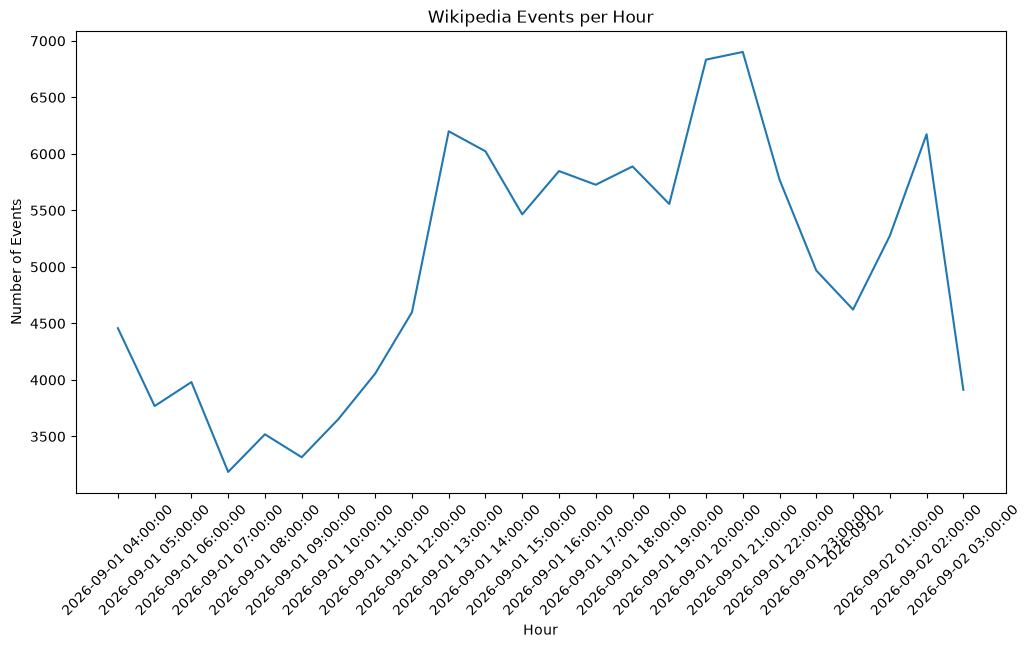

In [48]:
# first plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_counts, x="file_ts", y="event_count")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour")
plt.xticks(rotation=45)
plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")

plt.show()

In [49]:
hourly_type_counts = (hour_df.groupby(["file_ts", "type"]).size().reset_index(name="event_count"))

hourly_type_counts.head()

,file_ts,type,event_count
0,2026-09-01 04:00:00,edit,3959
1,2026-09-01 04:00:00,log,440
2,2026-09-01 04:00:00,new,59
3,2026-09-01 05:00:00,edit,3429
4,2026-09-01 05:00:00,log,199


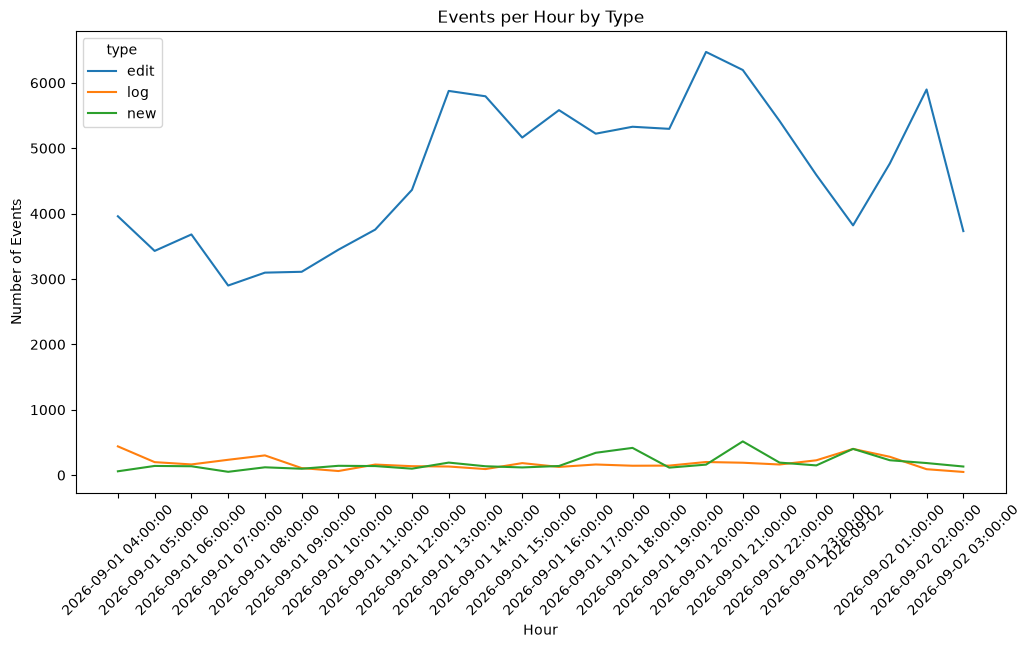

In [50]:
# second plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_type_counts, x="file_ts", y="event_count", hue="type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Events per Hour by Type")
plt.xticks(rotation=45)
plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")
plt.show()